In [ ]:
import os
if os.path.basename(os.getcwd()) != 'nuclei-segmentation':
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

# 🔬 Data Science Bowl 2018 — Exploratory Data Analysis
Nuclei Segmentation Dataset

## 0. Imports & Config

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── ΑΛΛΑΞΕ ΑΥΤΟ αν το path σου είναι διαφορετικό ──
TRAIN_DIR = Path('./data/raw/train')
TEST_DIR = Path('./data/raw/test')

print(f'Train dir exists: {TRAIN_DIR.exists()}')
print(f'Test dir exists: {TEST_DIR.exists()}')

Train dir exists: True
Test dir exists: True


## 1. Φόρτωση Metadata

In [2]:
def collect_metadata(data_dir, has_masks=True):
    """Διαβάζει όλα τα image IDs και μαζεύει metadata."""
    
    records = []
    image_ids = sorted(os.listdir(data_dir))

    for img_id in tqdm(image_ids, desc='Loading metadata'):
        img_path = data_dir / img_id / 'images' / f'{img_id}.png'

        if not img_path.exists():
            continue

        img = np.array(Image.open(img_path))

        h, w = img.shape[:2]
        channels = img.shape[2] if img.ndim == 3 else 1

        is_gray = (
            (channels == 1)
            or (
                img.ndim == 3
                and np.allclose(img[:, :, 0], img[:, :, 1])
                and np.allclose(img[:, :, 1], img[:, :, 2])
            )
        )

        mean_brightness = img.mean()

        n_masks = 0
        if has_masks:
            mask_dir = data_dir / img_id / 'masks'
            n_masks = (
                len(list(mask_dir.glob('*.png')))
                if mask_dir.exists()
                else 0
            )

        records.append({
            'image_id': img_id,
            'height': h,
            'width': w,
            'channels': channels,
            'is_grayscale': is_gray,
            'mean_brightness': mean_brightness,
            'n_nuclei': n_masks,
            'aspect_ratio': w / h,
        })

    return pd.DataFrame(records)


df_train = collect_metadata(TRAIN_DIR, has_masks=True)
df_test = collect_metadata(TEST_DIR, has_masks=False)

print(f'\nTrain: {len(df_train)} images')
print(f'Test: {len(df_test)} images')

df_train.head()

Loading metadata: 100%|██████████| 65/65 [00:00<00:00, 125.00it/s]


Train: 670 images
Test: 65 images


,image_id,height,width,channels,is_grayscale,mean_brightness,n_nuclei,aspect_ratio
0,00071198d059ba7f5914a526d124d28e6d010c92466da2...,256,256,4,True,68.356670,27,1.00
1,003cee89357d9fe13516167fd67b609a164651b2193458...,256,256,4,True,70.513950,36,1.00
2,00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b074...,256,320,4,False,194.888177,70,1.25
3,0121d6759c5adb290c8e828fc882f37dfaf3663ec885c6...,256,320,4,False,201.984433,86,1.25
4,01d44a26f6680c42ba94c9bc6339228579a95d0e2695b1...,256,320,4,False,196.243127,7,1.25


## 2. Βασικά Στατιστικά

In [3]:
print('=' * 50)
print('TRAIN SET STATISTICS')
print('=' * 50)
print(f"\nImage sizes (H x W):")
print(f" Min: {df_train['height'].min()} x {df_train['width'].min()}")
print(f" Max: {df_train['height'].max()} x {df_train['width'].max()}")
print(f" Mean: {df_train['height'].mean():.0f} x {df_train['width'].mean():.0f}")

print(f"\nNuclei per image:")
print(f" Min: {df_train['n_nuclei'].min()}")
print(f" Max: {df_train['n_nuclei'].max()}")
print(f" Mean: {df_train['n_nuclei'].mean():.1f}")
print(f" Total: {df_train['n_nuclei'].sum()}")

print(f"\nImage type:")
print(f" Grayscale: {df_train['is_grayscale'].sum()} ({df_train['is_grayscale'].mean()*100:.1f}%)")
print(f" Color: {(~df_train['is_grayscale']).sum()} ({(~df_train['is_grayscale']).mean()*100:.1f}%)")

# Κατηγοριοποίηση brightness
df_train['brightness_type'] = pd.cut(df_train['mean_brightness'], 
 bins=[0, 85, 170, 255], 
 labels=['Dark', 'Medium', 'Bright'])
print(f"\nBrightness distribution:")
print(df_train['brightness_type'].value_counts())

TRAIN SET STATISTICS

Image sizes (H x W):
 Min: 256 x 256
 Max: 1040 x 1388
 Mean: 334 x 378

Nuclei per image:
 Min: 1
 Max: 375
 Mean: 44.0
 Total: 29461

Image type:
 Grayscale: 562 (83.9%)
 Color: 108 (16.1%)

Brightness distribution:
brightness_type
Dark      517
Bright    122
Medium     31
Name: count, dtype: int64


## 3. Οπτικοποίηση Κατανομών

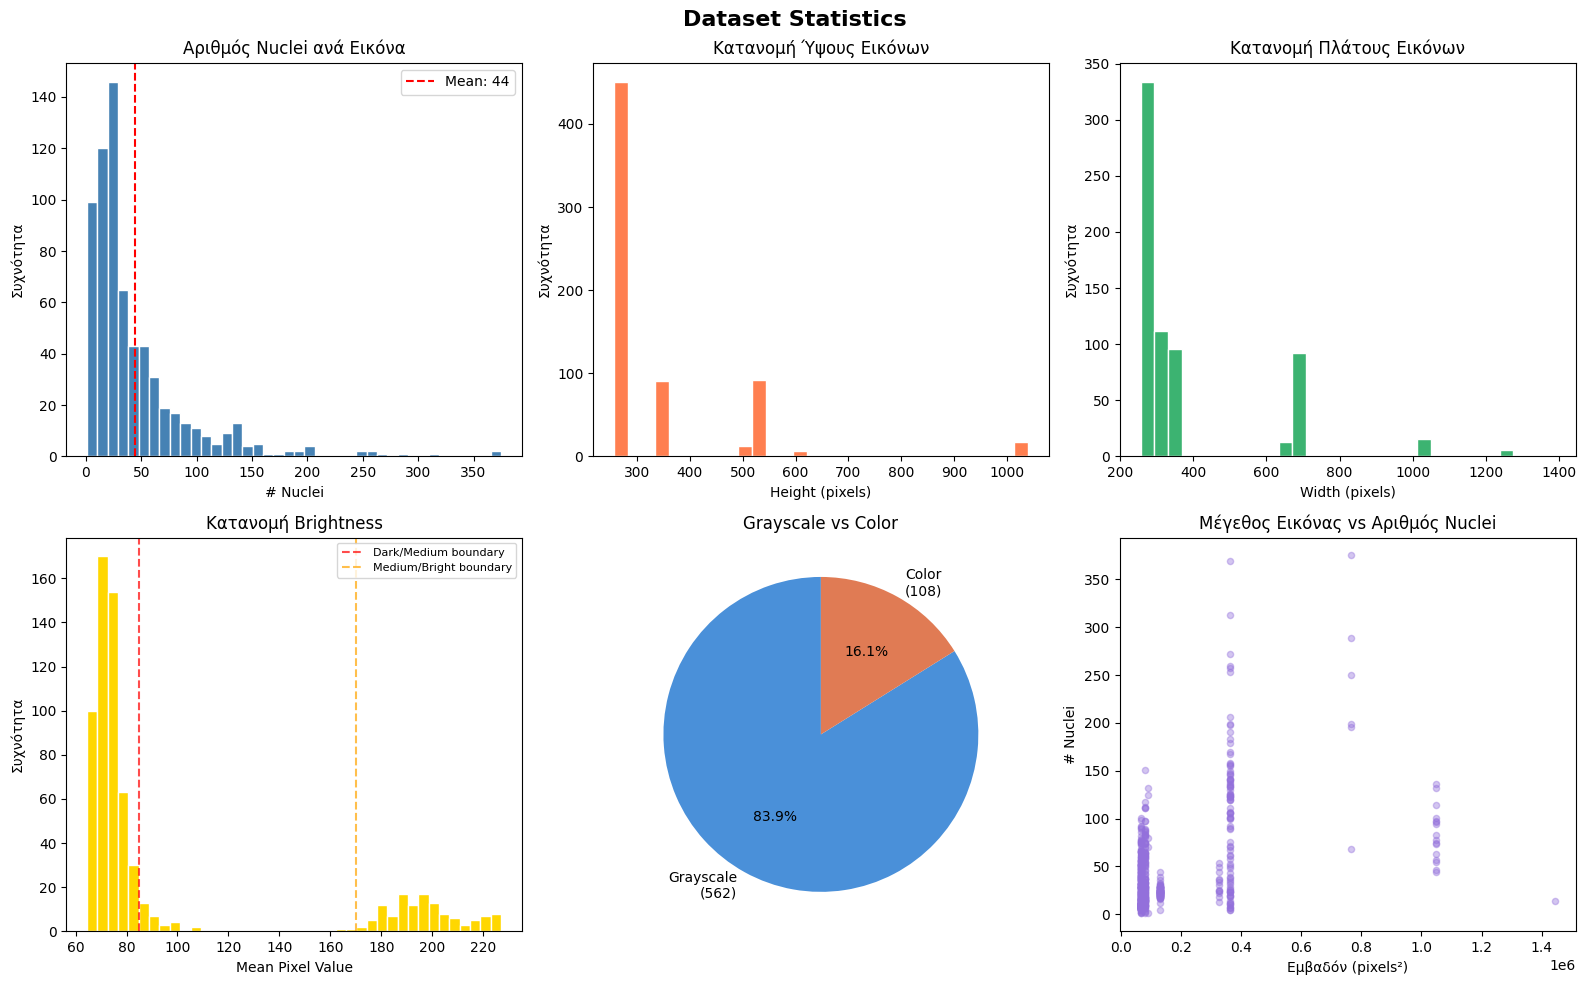

Αποθηκεύτηκε: outputs/eda_statistics.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Dataset Statistics', fontsize=16, fontweight='bold')

# 1. Nuclei per image
axes[0,0].hist(df_train['n_nuclei'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Αριθμός Nuclei ανά Εικόνα')
axes[0,0].set_xlabel('# Nuclei')
axes[0,0].set_ylabel('Συχνότητα')
axes[0,0].axvline(df_train['n_nuclei'].mean(), color='red', linestyle='--', label=f"Mean: {df_train['n_nuclei'].mean():.0f}")
axes[0,0].legend()

# 2. Image Heights
axes[0,1].hist(df_train['height'], bins=30, color='coral', edgecolor='white')
axes[0,1].set_title('Κατανομή Ύψους Εικόνων')
axes[0,1].set_xlabel('Height (pixels)')
axes[0,1].set_ylabel('Συχνότητα')

# 3. Image Widths
axes[0,2].hist(df_train['width'], bins=30, color='mediumseagreen', edgecolor='white')
axes[0,2].set_title('Κατανομή Πλάτους Εικόνων')
axes[0,2].set_xlabel('Width (pixels)')
axes[0,2].set_ylabel('Συχνότητα')

# 4. Mean Brightness
axes[1,0].hist(df_train['mean_brightness'], bins=40, color='gold', edgecolor='white')
axes[1,0].set_title('Κατανομή Brightness')
axes[1,0].set_xlabel('Mean Pixel Value')
axes[1,0].set_ylabel('Συχνότητα')
axes[1,0].axvline(85, color='red', linestyle='--', alpha=0.7, label='Dark/Medium boundary')
axes[1,0].axvline(170, color='orange', linestyle='--', alpha=0.7, label='Medium/Bright boundary')
axes[1,0].legend(fontsize=8)

# 5. Grayscale vs Color pie
gray_count = df_train['is_grayscale'].sum()
color_count = len(df_train) - gray_count
axes[1,1].pie([gray_count, color_count], 
 labels=[f'Grayscale\n({gray_count})', f'Color\n({color_count})'],
 colors=['#4a90d9', '#e07b54'],
 autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Grayscale vs Color')

# 6. Scatter: image size vs n_nuclei
area = df_train['height'] * df_train['width']
axes[1,2].scatter(area, df_train['n_nuclei'], alpha=0.4, color='mediumpurple', s=20)
axes[1,2].set_title('Μέγεθος Εικόνας vs Αριθμός Nuclei')
axes[1,2].set_xlabel('Εμβαδόν (pixels²)')
axes[1,2].set_ylabel('# Nuclei')

plt.tight_layout()
plt.savefig('./outputs/eda_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Αποθηκεύτηκε: outputs/eda_statistics.png')

## 4. Visualize Εικόνες + Masks

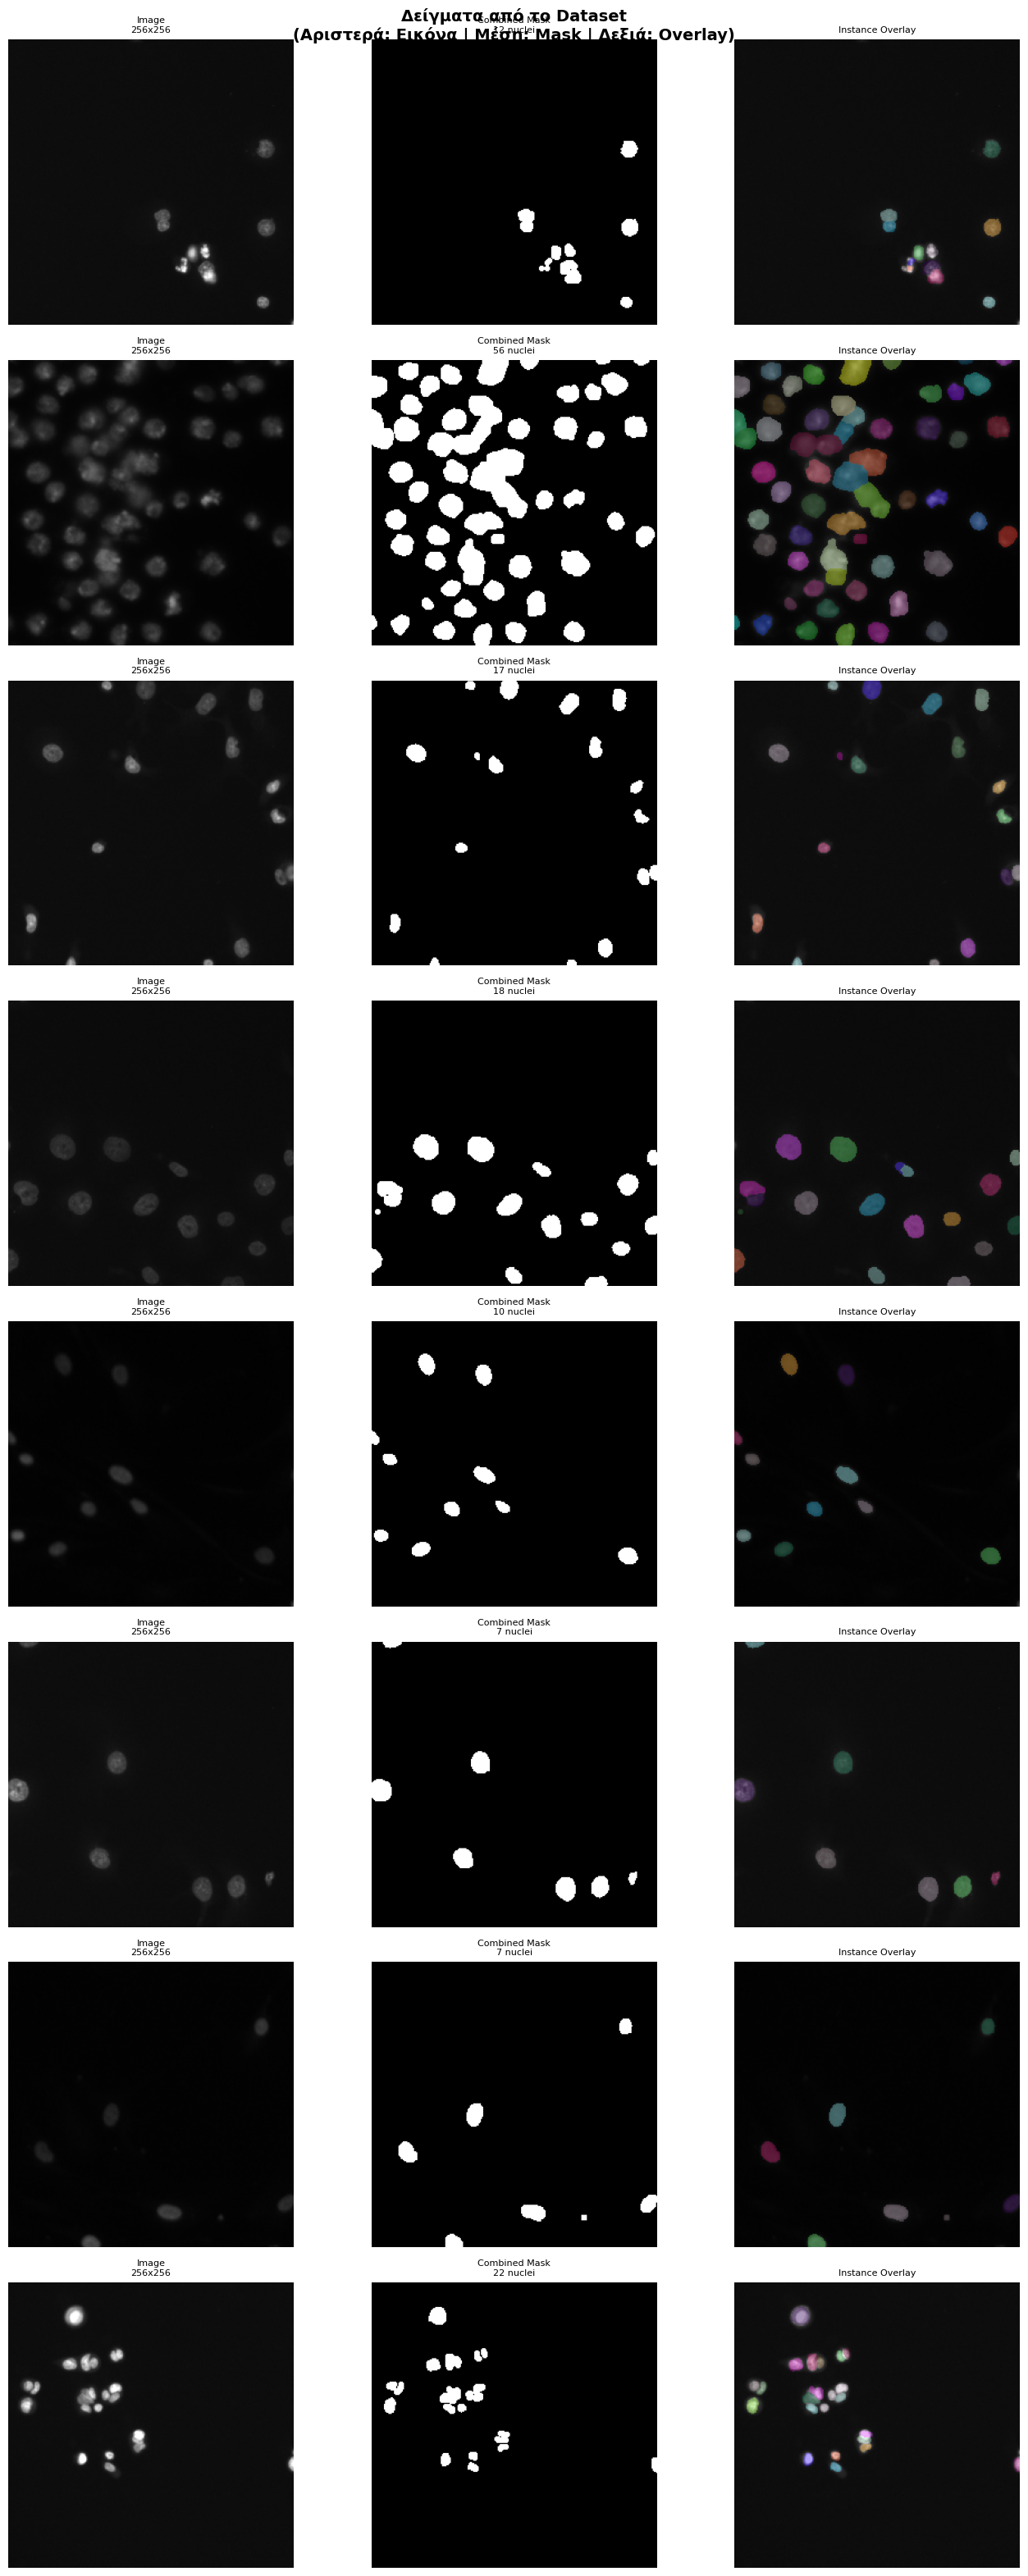

Αποθηκεύτηκε: outputs/eda_samples.png


In [5]:
def load_image_and_masks(data_dir, img_id):
    """Φορτώνει εικόνα και συνδυάζει ΟΛΑ τα masks σε ένα."""

    img_path = data_dir / img_id / 'images' / f'{img_id}.png'
    img = np.array(Image.open(img_path))

    # Συνδυασμός masks: κάθε nucleus παίρνει διαφορετική τιμή
    # (για instance segmentation)
    mask_dir = data_dir / img_id / 'masks'

    h, w = img.shape[:2]
    combined_mask = np.zeros((h, w), dtype=np.uint16)

    if mask_dir.exists():
        for i, mask_file in enumerate(
            sorted(mask_dir.glob('*.png')),
            start=1
        ):
            m = np.array(Image.open(mask_file).convert('L'))
            combined_mask[m > 0] = i

    return img, combined_mask


def overlay_mask(img, mask, alpha=0.4):
    """Overlay το instance mask πάνω στην εικόνα με χρώματα."""

    if img.ndim == 2:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    elif img.shape[2] == 4:
        img_rgb = img[:, :, :3].copy()

    else:
        img_rgb = img.copy()

    overlay = img_rgb.copy().astype(np.float32)

    n_instances = mask.max()

    np.random.seed(42)
    colors = np.random.randint(
        0,
        255,
        size=(n_instances + 1, 3)
    )

    for i in range(1, n_instances + 1):
        region = mask == i
        overlay[region] = colors[i]

    result = (
        img_rgb.astype(np.float32) * (1 - alpha)
        + overlay * alpha
    ).astype(np.uint8)

    return result


# Εμφάνισε 8 τυχαίες εικόνες
sample_ids = df_train.sample(
    8,
    random_state=42
)['image_id'].tolist()

fig, axes = plt.subplots(
    8,
    3,
    figsize=(14, 32)
)

fig.suptitle(
    'Δείγματα από το Dataset\n'
    '(Αριστερά: Εικόνα | Μέση: Mask | Δεξιά: Overlay)',
    fontsize=14,
    fontweight='bold'
)

for row, img_id in enumerate(sample_ids):

    img, mask = load_image_and_masks(
        TRAIN_DIR,
        img_id
    )

    n_nuclei = mask.max()

    # Εικόνα
    axes[row, 0].imshow(
        img,
        cmap='gray' if img.ndim == 2 else None
    )

    axes[row, 0].set_title(
        f'Image\n{img.shape[1]}x{img.shape[0]}',
        fontsize=8
    )

    axes[row, 0].axis('off')

    # Mask (binary)
    binary_mask = (
        (mask > 0).astype(np.uint8) * 255
    )

    axes[row, 1].imshow(
        binary_mask,
        cmap='gray'
    )

    axes[row, 1].set_title(
        f'Combined Mask\n{n_nuclei} nuclei',
        fontsize=8
    )

    axes[row, 1].axis('off')

    # Overlay
    overlay = overlay_mask(img, mask)

    axes[row, 2].imshow(overlay)

    axes[row, 2].set_title(
        'Instance Overlay',
        fontsize=8
    )

    axes[row, 2].axis('off')

plt.tight_layout()

plt.savefig(
    './outputs/eda_samples.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()

print('Αποθηκεύτηκε: outputs/eda_samples.png')

## 5. Dataset Diversity — Τύποι Εικόνων

Κατανομή τύπων εικόνων:
image_type
Dark Grayscale              546
Bright Color (Histology)    108
Bright Grayscale             16
Name: count, dtype: int64


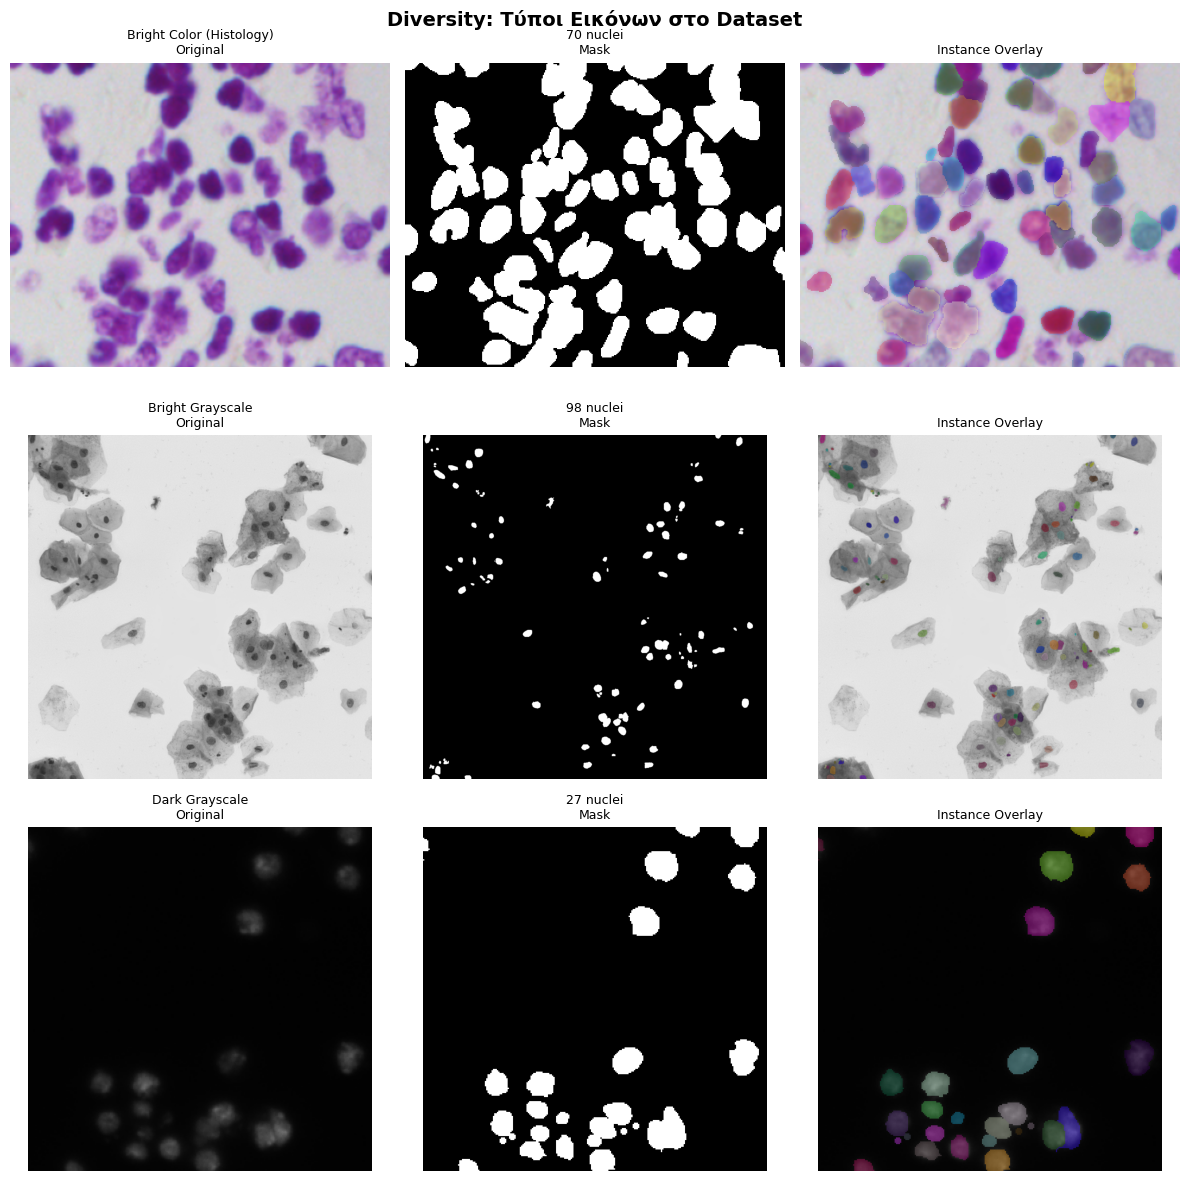

Αποθηκεύτηκε: outputs/eda_diversity.png


In [6]:
# Κατηγοριοποίηση σε 4 τύπους βάσει brightness + color
def classify_image_type(row):
    if row['is_grayscale'] and row['mean_brightness'] < 128:
        return 'Dark Grayscale'
    elif row['is_grayscale'] and row['mean_brightness'] >= 128:
        return 'Bright Grayscale'
    elif not row['is_grayscale'] and row['mean_brightness'] < 128:
        return 'Dark Color (Fluorescence)'
    else:
        return 'Bright Color (Histology)'


df_train['image_type'] = df_train.apply(classify_image_type, axis=1)

print('Κατανομή τύπων εικόνων:')
print(df_train['image_type'].value_counts())

# Εμφάνισε 2 παραδείγματα από κάθε τύπο
types = df_train['image_type'].unique()
fig, axes = plt.subplots(len(types), 3, figsize=(12, 4 * len(types)))
fig.suptitle('Diversity: Τύποι Εικόνων στο Dataset', fontsize=14, fontweight='bold')

for row_idx, img_type in enumerate(sorted(types)):
    sample = df_train[df_train['image_type'] == img_type].iloc[0]
    img, mask = load_image_and_masks(TRAIN_DIR, sample['image_id'])
    
    axes[row_idx, 0].imshow(img, cmap='gray' if img.ndim == 2 else None)
    axes[row_idx, 0].set_title(f'{img_type}\nOriginal', fontsize=9)
    axes[row_idx, 0].axis('off')
    
    axes[row_idx, 1].imshow((mask > 0).astype(np.uint8) * 255, cmap='gray')
    axes[row_idx, 1].set_title(f'{mask.max()} nuclei\nMask', fontsize=9)
    axes[row_idx, 1].axis('off')
    
    axes[row_idx, 2].imshow(overlay_mask(img, mask))
    axes[row_idx, 2].set_title('Instance Overlay', fontsize=9)
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.savefig('./outputs/eda_diversity.png', dpi=120, bbox_inches='tight')
plt.show()
print('Αποθηκεύτηκε: outputs/eda_diversity.png')

## 6. Class Imbalance — Nucleus vs Background

Υπολογισμός nucleus/background ratio (σε sample 50 εικόνων)...


100%|██████████| 50/50 [00:01<00:00, 44.44it/s]



Μέσο % pixels που είναι nucleus: 13.84%
Μέσο % pixels που είναι background: 86.16%

→ Class imbalance ratio: 1 : 6.2 (nucleus:background)


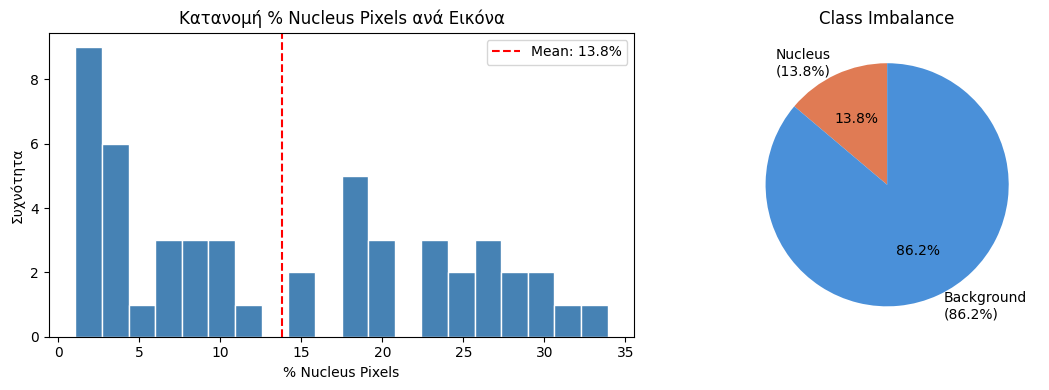

In [7]:
print('Υπολογισμός nucleus/background ratio (σε sample 50 εικόνων)...')

ratios = []
sample_ids_balance = df_train.sample(50, random_state=0)['image_id'].tolist()

for img_id in tqdm(sample_ids_balance):
 _, mask = load_image_and_masks(TRAIN_DIR, img_id)
 total_pixels = mask.size
 nucleus_pixels = (mask > 0).sum()
 ratios.append(nucleus_pixels / total_pixels * 100)

mean_ratio = np.mean(ratios)
print(f'\nΜέσο % pixels που είναι nucleus: {mean_ratio:.2f}%')
print(f'Μέσο % pixels που είναι background: {100-mean_ratio:.2f}%')
print(f'\n→ Class imbalance ratio: 1 : {(100-mean_ratio)/mean_ratio:.1f} (nucleus:background)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ratios, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Κατανομή % Nucleus Pixels ανά Εικόνα')
axes[0].set_xlabel('% Nucleus Pixels')
axes[0].set_ylabel('Συχνότητα')
axes[0].axvline(mean_ratio, color='red', linestyle='--', label=f'Mean: {mean_ratio:.1f}%')
axes[0].legend()

axes[1].pie([mean_ratio, 100-mean_ratio],
 labels=[f'Nucleus\n({mean_ratio:.1f}%)', f'Background\n({100-mean_ratio:.1f}%)'],
 colors=['#e07b54', '#4a90d9'],
 autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Imbalance')

plt.tight_layout()
plt.savefig('./outputs/eda_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Unique Image Sizes

Unique image sizes: 9

Top 10 sizes:
 height  width  count
    256    256    334
    256    320    112
    520    696     92
    360    360     91
   1024   1024     16
    512    640     13
    603   1272      6
    260    347      5
   1040   1388      1


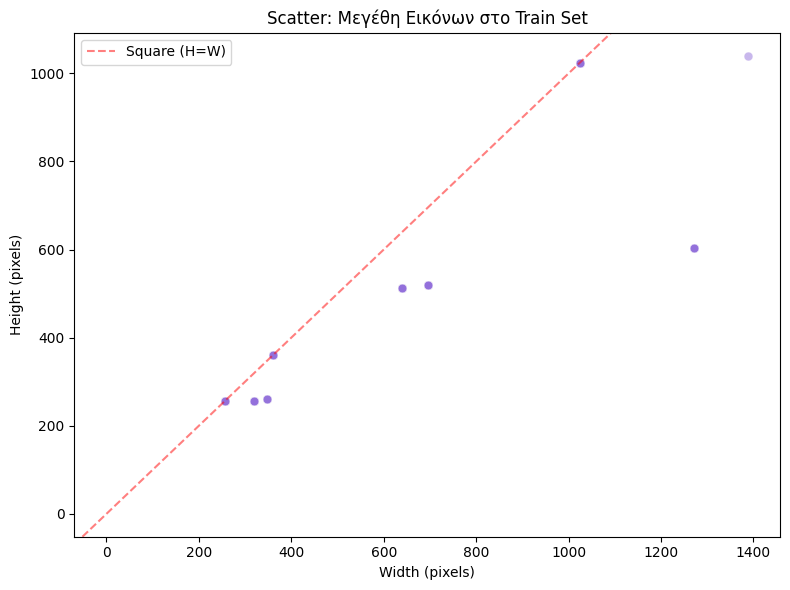

In [8]:
size_counts = df_train.groupby(['height', 'width']).size().reset_index(name='count')
size_counts = size_counts.sort_values('count', ascending=False)

print(f'Unique image sizes: {len(size_counts)}')
print('\nTop 10 sizes:')
print(size_counts.head(10).to_string(index=False))

# Scatter plot όλων των sizes
plt.figure(figsize=(8, 6))
plt.scatter(df_train['width'], df_train['height'], 
 alpha=0.5, s=40, color='mediumpurple', edgecolors='white', linewidth=0.5)
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.title('Scatter: Μεγέθη Εικόνων στο Train Set')
plt.axline((0,0), slope=1, color='red', linestyle='--', alpha=0.5, label='Square (H=W)')
plt.legend()
plt.tight_layout()
plt.savefig('./outputs/eda_image_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Αποθήκευση Metadata

In [9]:
df_train.to_csv('./outputs/train_metadata.csv', index=False)
df_test.to_csv('./outputs/test_metadata.csv', index=False)
print('Αποθηκεύτηκαν: outputs/train_metadata.csv και test_metadata.csv')
print('\n=== ΣΥΝΟΨΗ ===')
print(f'Training images: {len(df_train)}')
print(f'Test images: {len(df_test)}')
print(f'Total nuclei: {df_train["n_nuclei"].sum()}')
print(f'Avg nuclei/image: {df_train["n_nuclei"].mean():.1f}')
print(f'Unique image sizes: {len(size_counts)}')
print(f'Grayscale images: {df_train["is_grayscale"].sum()} ({df_train["is_grayscale"].mean()*100:.0f}%)')
print(f'Color images: {(~df_train["is_grayscale"]).sum()} ({(~df_train["is_grayscale"]).mean()*100:.0f}%)')
print(f'Avg nucleus coverage: {mean_ratio:.2f}% of pixels')

Αποθηκεύτηκαν: outputs/train_metadata.csv και test_metadata.csv

=== ΣΥΝΟΨΗ ===
Training images: 670
Test images: 65
Total nuclei: 29461
Avg nuclei/image: 44.0
Unique image sizes: 9
Grayscale images: 562 (84%)
Color images: 108 (16%)
Avg nucleus coverage: 13.84% of pixels
